In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [70]:
SEED=42
np.random.seed(SEED)

In [71]:
df=pd.read_csv('/content/customer_segemntation.csv')

In [72]:
df.sample(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
324,2607,1953,Graduation,Single,40464.0,0,1,11-01-2013,78,424,...,8,0,0,0,0,0,0,3,11,0
96,7247,1960,Graduation,Widow,47916.0,0,1,22-11-2012,72,505,...,6,0,1,0,0,0,0,3,11,0
2104,5802,1972,Basic,Married,14188.0,0,0,28-02-2013,40,2,...,6,0,0,0,0,0,0,3,11,0
1259,2147,1969,Graduation,Together,76653.0,0,0,16-08-2013,91,736,...,2,0,0,1,1,0,0,3,11,0
1061,3759,1958,Graduation,Together,65196.0,0,2,25-07-2013,34,743,...,5,1,0,0,0,0,0,3,11,0
1805,9284,1958,Graduation,Together,53977.0,0,1,08-06-2013,21,620,...,5,0,0,0,0,0,0,3,11,0
916,10505,1960,Master,Together,73113.0,0,0,26-12-2013,86,741,...,2,0,0,0,0,0,0,3,11,0
350,2579,1957,Graduation,Married,71113.0,0,1,17-12-2013,95,495,...,4,0,0,0,0,0,0,3,11,0
1901,10779,1983,Graduation,Single,22148.0,0,0,13-04-2014,16,15,...,7,0,0,0,0,0,0,3,11,0
1650,8079,1982,Graduation,Married,22448.0,1,0,26-02-2014,86,3,...,3,0,0,0,0,0,0,3,11,0


In [73]:
df.shape

(2240, 29)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [75]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [76]:
# df.dropna(inplace=True)
df['Income']=df['Income'].fillna(df['Income'].median())

In [77]:
df['Income'].isnull().sum()

np.int64(0)

In [78]:
df.nunique()

,0
ID,2240
Year_Birth,59
Education,5
Marital_Status,8
Income,1975
Kidhome,3
Teenhome,3
Dt_Customer,663
Recency,100
MntWines,776


In [79]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")

In [80]:
# df["day"]=df["Dt_Customer"].dt.day
# df["month"]=df["Dt_Customer"].dt.month
# df['year']=df['Dt_Customer'].dt.year

In [81]:
df['Age']=2026-df['Year_Birth']

In [82]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,42
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,45


In [83]:
df['Children']=df['Kidhome']+df['Teenhome']

In [84]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [85]:
df['Total_spending']=df['MntWines']+df['MntFruits']+df['MntFishProducts']+df['MntGoldProds']+df['MntMeatProducts']+df['MntSweetProducts']

In [86]:
df['Total_purchases']=df['NumCatalogPurchases']+df['NumStorePurchases']+df['NumWebPurchases']

In [87]:
campaign_cols=["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]
df['Campaign_acceptance']=df[campaign_cols].sum(axis=1)

In [88]:
df['customer_days']=(pd.Timestamp("today")-df['Dt_Customer']).dt.days

In [89]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Children,Total_spending,Total_purchases,Campaign_acceptance,customer_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,69,0,1617,22,1,5022
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,72,2,27,4,0,4472
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,61,0,776,20,0,4671
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,42,1,53,6,0,4498
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,45,1,422,14,0,4520


In [90]:
df.drop(['ID','Year_Birth','Dt_Customer','Z_CostContact','Z_Revenue'],axis=1,inplace=True)

In [91]:
df.shape

(2240, 30)

In [92]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Education']=le.fit_transform(df["Education"])
df['Marital_Status']=le.fit_transform(df["Marital_Status"])

In [93]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X=scaler.fit_transform(df)

In [94]:
wcss=[]
for k in range(2,11):
  kmeans=KMeans(
      n_clusters=k,
      random_state=42
  )
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

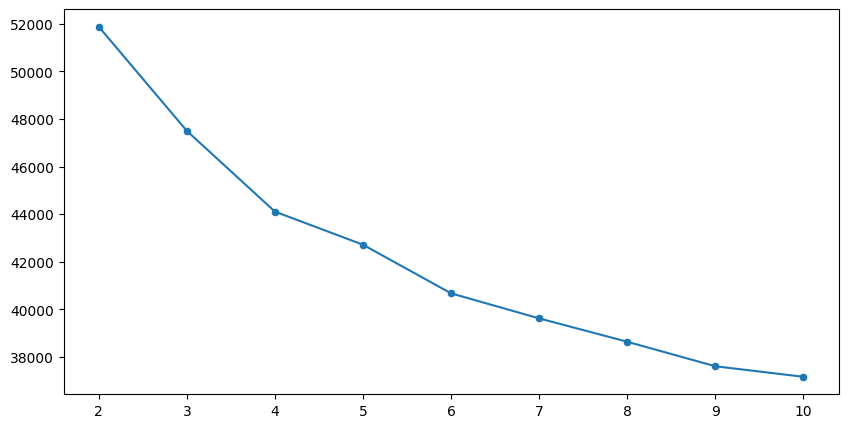

In [95]:
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(2, 11), y=wcss)
sns.scatterplot(x=range(2, 11), y=wcss)
plt.show()

In [96]:
from sklearn.metrics import silhouette_score
for k in range(2,11):
  model=KMeans(
      n_clusters=k,
      random_state=42
  )
  labels=model.fit_predict(X)
  score=silhouette_score(X,labels)
  print(k,score)

2 0.2516419217562264
3 0.17556577682550012
4 0.1772615828517448
5 0.0986289691818265
6 0.10591865036354475
7 0.09999932300037837
8 0.109288452393339
9 0.10873742957243314
10 0.10329508640986683


In [97]:
kmeans=KMeans(n_clusters=2,
              random_state=42)
df['cluster']=kmeans.fit_predict(X)

In [98]:
cluster_summary=df.groupby("cluster").mean()

/tmp/ipykernel_3114/240872752.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=feature, data=cluster_summary, palette='viridis')
/tmp/ipykernel_3114/240872752.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=feature, data=cluster_summary, palette='viridis')
/tmp/ipykernel_3114/240872752.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=feature, data=cluster_summary, palette='viridis')
/tmp/ipykernel_3114/240872752.py:7: FutureWarning: 

Passing `palette`

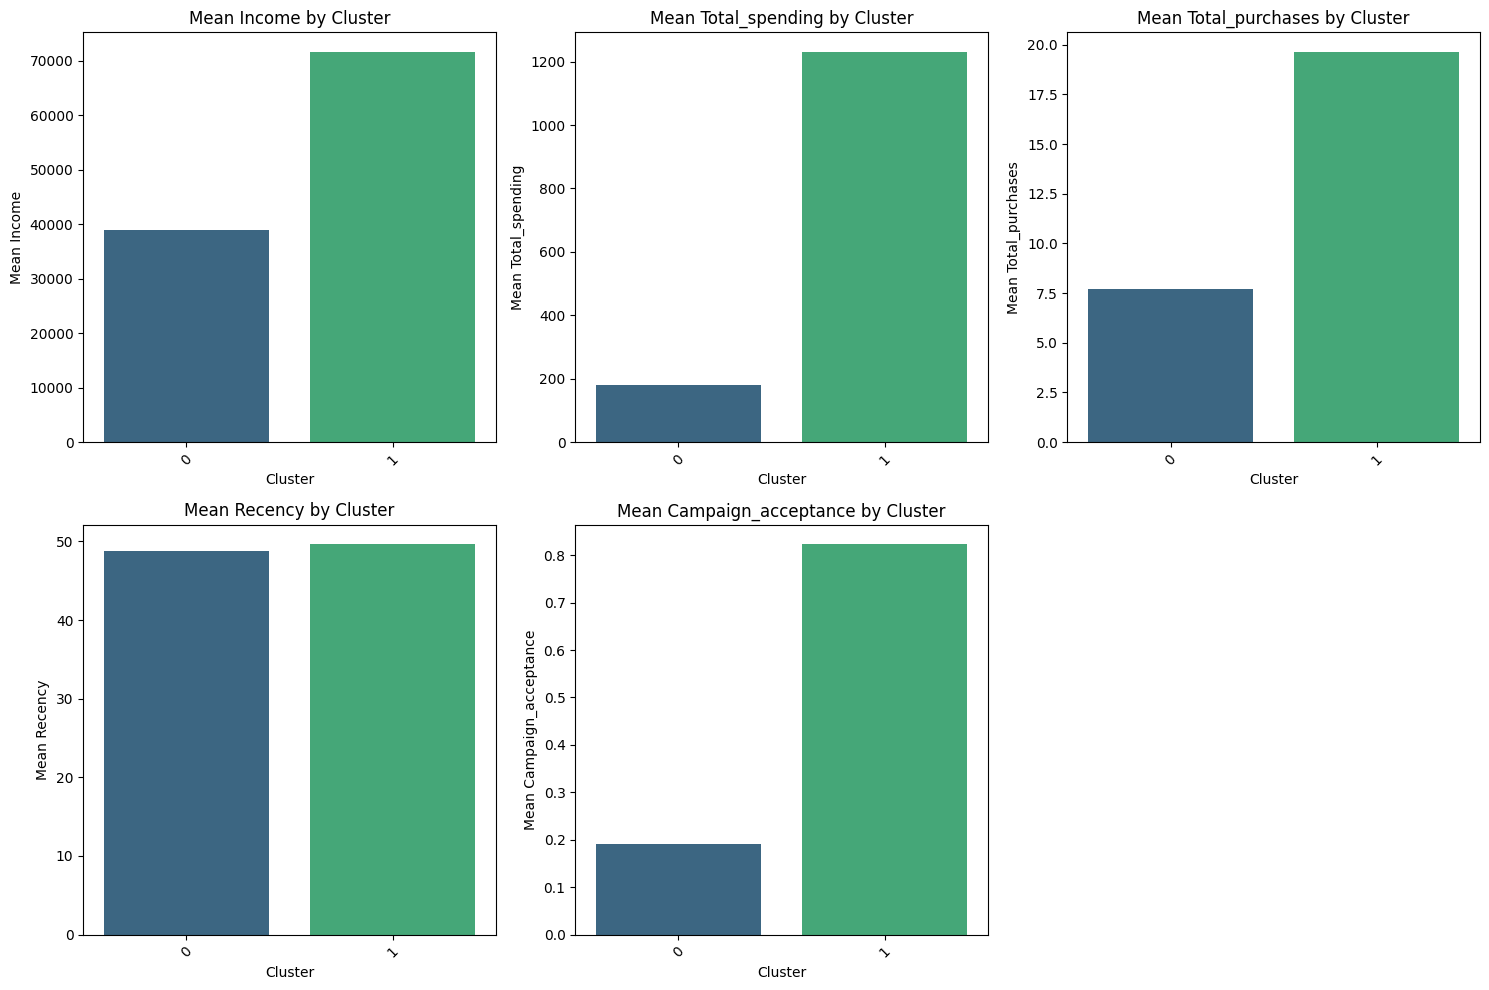

In [99]:
plt.figure(figsize=(15, 10))

features = ['Income', 'Total_spending', 'Total_purchases', 'Recency', 'Campaign_acceptance']

for i, feature in enumerate(features):
    plt.subplot(2, 3, i + 1) # 2 rows, 3 columns
    sns.barplot(x=cluster_summary.index, y=feature, data=cluster_summary, palette='viridis')
    plt.title(f'Mean {feature} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(f'Mean {feature}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Based on the visualizations:

*   **Cluster 0:** Tends to have lower income, lower total spending, lower total purchases, higher recency (meaning they purchased less recently), and lower campaign acceptance. These could be considered "Budget Customers" or "Lower Engagement Customers."

*   **Cluster 1:** Tends to have higher income, higher total spending, higher total purchases, lower recency (meaning they purchased more recently), and higher campaign acceptance. These could be considered "High Value Customers" or "Engaged Customers."

In [100]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)

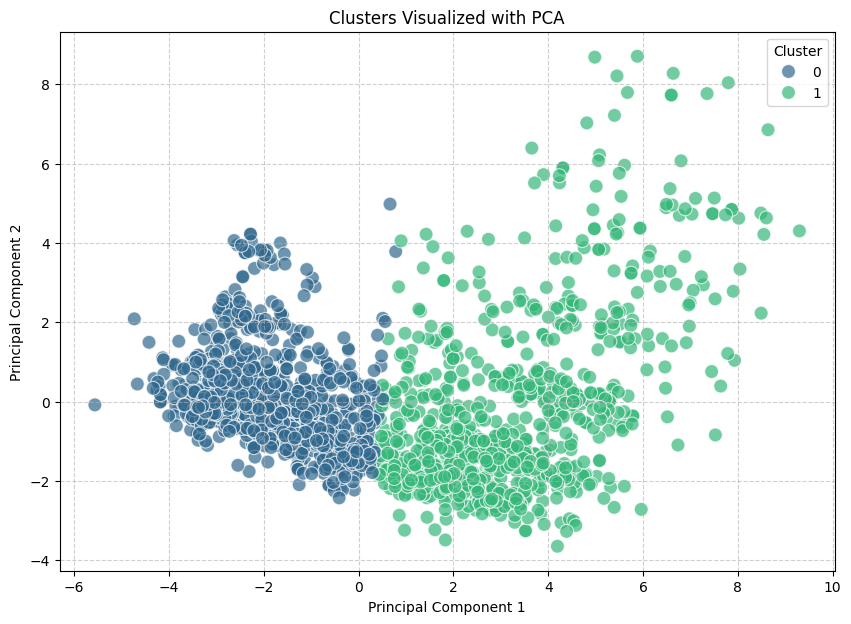

In [101]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster'], palette='viridis', s=100, alpha=0.7)
plt.title('Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()